VarDial 2026 Submission

Submitted on January 2, 2026

## Table of Contents
0. Libraries
1. Data Sourcing & Pre-processing
2. Trigram Profile Generation
3. Cosine Similarity
4. Dendrogram
5. Evaluation

---

## Running this Notebook:
- Make sure you have Python 3.12.0 installed, or set as the Python version of your kernel.
- To install the requirements, run `pip install -r requirements.txt`
```

## **0. Libraries**

The following Python libraries/methods were used for this project. It is necessary to install the ones with attached comments through the CLI. 

**pathlib - Path** - used to manipulate the current directory of the notebook for correct file pathfinding

**pandas** - standard data science library used for the creation of the dendrogram

**scipy - dendrogram, linkage** - used to perform hierarchical clustering and create the dendrogram

**matplotlib.pyplot** - used to display the dendrogram

**nltk - ngrams** - used to generate trigram profiles

In [2]:
from pathlib import Path    # pip install pathlib
import pandas as pd         # pip install pandas
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from collections import Counter

The code below is just to create a list for iterating through our language files. If someone wishes to add or remove languages in their own recreation of this project, they can edit this list.

The following code block is commented out as this only needs to be run once. Once this has been run once, or if you already have these libraries installed, **DO NOT** run this code block again, as it will cause issues. Comment it out or run only the code blocks below it instead.

In [3]:
#needed for nltk, you can just run this once
'''
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('popular')'''

"\nnltk.download('punkt')\nnltk.download('punkt_tab')\nnltk.download('popular')"

In [4]:
languages = ["spanish", "tagalog", "english", "hiligaynon", "bikol", "waray", "ilocano", "cebuano", "kapampangan", "pangasinense", "yakan", "ivatan", "tausug", "yami", "tuwali_ifugao", "masbateno"]

## **1. Data Sources & Pre-processing**

Data for this study was taken from multiple sources, such as the YouVersion Bible translations, literary text, articles, etc. Some of the data was sourced from the PALITO corpus, found in the personal corpora database of Nathaniel Oco. The word count of each language's corpora is seen below:

| Language     | Corpora Word Count      |
| ------------- | ------------- |
| English | 288153 |
| Spanish | 272670 |
| Tagalog | 411305 |
| Hiligaynon |400783  |
| Bikol | 354554 |
| Waray | 423654 |
| Ilocano | 358963 |
| Cebuano | 395903 |
| Kapampangan | 402167 |
| Pangasinense | 407230 |
| Yakan | 218806 |
| Ivatan | 236424 |
| Tausug | 292663 |
| Yami | 260301 |
| Tuwali Ifugao | 216261 |
| Masbateno | 215948 |




## 2. Trigram Profile Generation
Once the corpora is loaded, each language's cleaned corpora is loaded and tokenized with NLTK's word_tokenize method. Afterwards, the full trigram profile of each langauge is created.

In [5]:
data_folder = Path("corpora")
output_folder = Path("all-trigrams")
word_counts = []

for lang in languages:
    # define source and output
    source_file_path = data_folder / f"{lang}-corpora.txt"
    output_file_path = output_folder/f"{lang}-all-trigrams.txt"

    # if source doesn't exist skip
    if not source_file_path.exists() or source_file_path.stat().st_size == 0:
            print(f"Skipped: {source_file_path} (file does not exist or is empty)")
            # continue
    else:       
        # rewrite all the txts if it exists
        if output_file_path.exists():
            print(f"unlinking/deleting old files")
            output_file_path.unlink()

        # read input
        with source_file_path.open("r", errors="ignore", encoding="utf-8") as f:
            raw_sentences = f.read()
            texts = word_tokenize(raw_sentences)
            print(lang + ": " + str(len(texts)))

        word_counts.append([lang, len(word_tokenize(raw_sentences))])
        characters = [c for c in raw_sentences]

        #get the trigrams
        trigrams = list(ngrams(characters, 3))

        # save them to the file
        with output_file_path.open("w", encoding="utf-8") as f:
            f.write("Trigrams\n")
            for list_tuple in trigrams:
                cleaned = ( '_' if (isinstance(ch, str) and ch.isspace()) else str(ch) for ch in list_tuple )
                f.write("".join(cleaned) + "\n")
            

        print(f"Cleaned and saved: {output_file_path}")


unlinking/deleting old files
spanish: 272670
Cleaned and saved: all-trigrams\spanish-all-trigrams.txt
unlinking/deleting old files
tagalog: 411305
Cleaned and saved: all-trigrams\tagalog-all-trigrams.txt
unlinking/deleting old files
english: 288153
Cleaned and saved: all-trigrams\english-all-trigrams.txt
unlinking/deleting old files
hiligaynon: 400783
Cleaned and saved: all-trigrams\hiligaynon-all-trigrams.txt
unlinking/deleting old files
bikol: 354554
Cleaned and saved: all-trigrams\bikol-all-trigrams.txt
unlinking/deleting old files
waray: 423654
Cleaned and saved: all-trigrams\waray-all-trigrams.txt
unlinking/deleting old files
ilocano: 358963
Cleaned and saved: all-trigrams\ilocano-all-trigrams.txt
unlinking/deleting old files
cebuano: 395903
Cleaned and saved: all-trigrams\cebuano-all-trigrams.txt
unlinking/deleting old files
kapampangan: 402167
Cleaned and saved: all-trigrams\kapampangan-all-trigrams.txt
unlinking/deleting old files
pangasinense: 407230
Cleaned and saved: all-tri

After generating the character trigrams found in each language's corpora, along with their respective frequencies, NLTK's most_common method was used to create updated trigram profiles containing only the 250 most common trigrams of each language, along with their frequency.

In [6]:
data_folder = Path("all-trigrams")
output_folder = Path("t250-trigrams")

for lang in languages:
    # define source and output
    source_file_path = data_folder / f"{lang}-all-trigrams.txt"
    output_file_path = output_folder/f"{lang}-t250.txt"

    # if source doesn't exist skip
    if not source_file_path.exists() or source_file_path.stat().st_size == 0:
            print(f"Skipped: {source_file_path} (file does not exist or is empty)")
            # continue
    else:       
        # rewrite all the txts if it exists
        if output_file_path.exists():
            print(f"unlinking/deleting old files")
            output_file_path.unlink()

        # read input
        with source_file_path.open("r", errors="ignore", encoding="utf-8") as f:
            #skip the first line
            next(f, None) 
            trigrams = [line.strip() for line in f if line.strip()]

        freq_counter = Counter(trigrams)
        top_250_trigrams = freq_counter.most_common(250)

        # save them to the file
        with output_file_path.open("w", encoding="utf-8") as f:
            f.write(f"{lang}top250\n")
            for trigram, count in top_250_trigrams:
                 f.write(f"{trigram} {count}\n")

        print(f"Cleaned and saved: {output_file_path}")
        

unlinking/deleting old files
Cleaned and saved: t250-trigrams\spanish-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\tagalog-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\english-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\hiligaynon-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\bikol-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\waray-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\ilocano-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\cebuano-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\kapampangan-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\pangasinense-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\yakan-t250.txt
unlinking/deleting old files
Cleaned and saved: t250-trigrams\ivatan-t250.txt
unlinking/deleting old files
Cleaned and saved:

## 3. Cosine Similarity

The following methods are defined for the process of computing the cosine similarity between each language pair. The read_top_counts methods returns a dictionary containing trigrams as the keys, and their respective count as the value. The build_count_matrix method creates a matrix containing the dictionary of trigrams. Afterwards, the l2_normalize method calculates the L2 normalization (also known as the Euclidean Norm) of each row in the matrix in order to ensure that each vector created has a length of 1.

In [7]:
# reads the trigram files, and returns a dictionary containing the trigram as the key and its count as the value
def read_top_counts(path):
    counts = {}
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        next(f, None)  # skip header like "englishTop250"
        for line in f:
            line = line.strip()
            if not line:
                continue
            # split from the right so trigrams containing spaces still work (if any)
            trigram, count_str = line.rsplit(" ", 1)
            counts[trigram] = int(count_str)
    return counts

# this builds a matrix of the counts
# rows are languages, columns are trigrams seen across the languages
# values are the trigram counts (0 if not in top 250)
def build_count_matrix(languages, t250_folder):
    docs = {} # lang -> {trigram: count}
    vocab = set() # all trigrams across all languages

    # load each language file and grow the shared vocabulary
    for lang in languages:
        p = t250_folder / f"{lang}-t250.txt"
        if not p.exists() or p.stat().st_size == 0:
            continue
        c = read_top_counts(p)
        docs[lang] = c
        vocab.update(c.keys())

    # freezes the vocab order so every row uses the same trigram column positions
    vocab = sorted(vocab)
    langs = list(docs.keys())
    # trigram -> column index
    term_to_col = {t: i for i, t in enumerate(vocab)} 

    # create the matrix and fill it with counts
    X = np.zeros((len(langs), len(vocab)), dtype=float)
    for r, lang in enumerate(langs):
        for term, count in docs[lang].items():
            X[r, term_to_col[term]] = count

    # wrap the matrix in a DataFrame with row/column labels
    return pd.DataFrame(X, index=langs, columns=vocab)

# L2-normalize each row so each language vector has length 1 so the cosine simlarity is just a dot prod
def l2_normalize_rows(df):
    X = df.to_numpy(dtype=float) # dataframe to numpy array
    norms = np.linalg.norm(X, axis=1, keepdims=True) # one norm per row
    X = X / (norms + 1e-12) # divide row by the norm
    return pd.DataFrame(X, index=df.index, columns=df.columns)

After creating the necessary vectors using the methods above, the cosine_similarity_matrix method seen below is used to compute the cosine similarity between each language pair.

In [8]:
# compute the all-vs-all cosine similarities; if rows are L2-normalized, cosine(A, B) = A dot B
def cosine_similarity_matrix(norm_df):
    # (n_langs, n_terms)
    X = norm_df.to_numpy(dtype=float) 
    #(n_langs, n_langs) similarity matrix
    S = X @ X.T 
    return pd.DataFrame(S, index=norm_df.index, columns=norm_df.index)

The cosine similarity matrix is built using the previously declared methods. Afterwards, it is exported as a CSV file for an external copy.

unlinking/deleting old files


<Axes: >

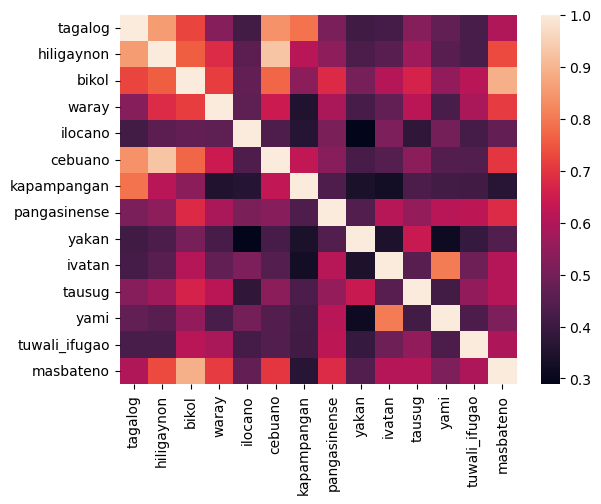

In [9]:
t250_folder = Path("t250-trigrams")
languages = ["tagalog","hiligaynon", "bikol", "waray", "ilocano", "cebuano", "kapampangan", "pangasinense", "yakan", "ivatan", "tausug", "yami", "tuwali_ifugao", "masbateno"]
# counts_df contains the trigram counts
counts_df = build_count_matrix(languages, t250_folder)

# norm_df contains the normalized version
norm_df = l2_normalize_rows(counts_df)

# sim_df has the cosine similarity matrix of all languages to all languages, feel free to print(sim_df)
sim_df = cosine_similarity_matrix(norm_df)

# export it to csv
csv_output_path = Path("cosine_similarity.csv")

# delete the old version if it already exists
if csv_output_path.exists():
    print(f"unlinking/deleting old files")
    csv_output_path.unlink()

sim_df.to_csv(csv_output_path)

# we'll be using new_df onwards
new_df = sim_df 
import seaborn as sns
sns.heatmap(new_df)

## 4. Clustering & Dendrogram

In order to create an appropriate visualization of the generated cosine similarity matrix, hierarchical clustering is first used to group similar languages together. Afterwards, the matplotlib library is used to create a dendrogram to represent the language tree.

In [10]:
pd.options.display.float_format = '{:.6f}'.format

# all-vs-all cosine similarity
dist_matrix = 1 - new_df

hc = linkage(dist_matrix, method='ward')

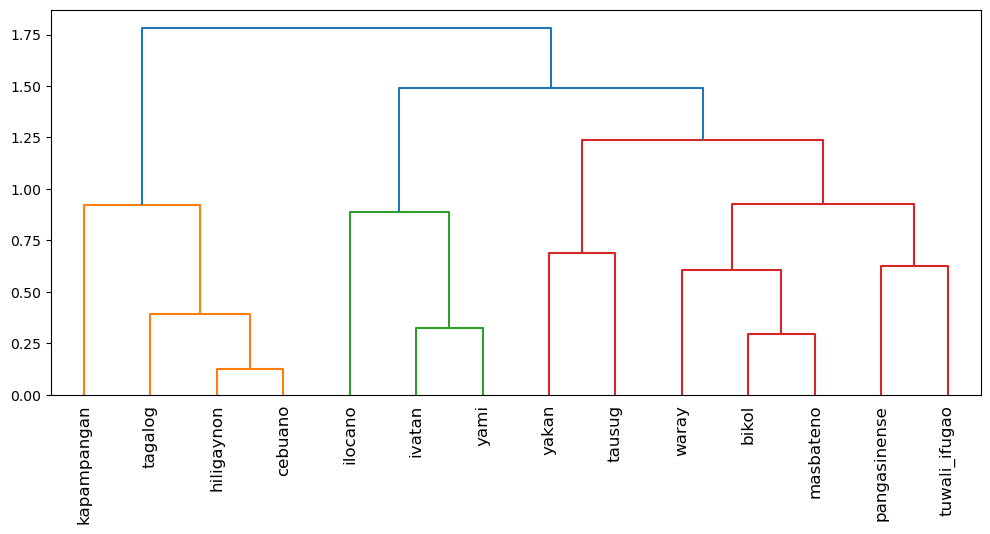

In [11]:
plt.figure(figsize=(12, 5))
dendrogram(hc, labels=dist_matrix.columns, leaf_rotation=90)
plt.show()

## 5. Evaluation

In order to evaluate the effectiveness of the proposed cosine similarity metric, the same method was applied to language pairs with existing lexical similarity scores (taken from Ethnologue). The German, Portuguese, Romanian, Italian, and French corpora consist of their respective translations of the New Testament, sourced from YouVersion's Bibles.

In [12]:
eval_languages = ["german", "portuguese", "romanian", "italian", "french"]

In [13]:
data_folder = Path("evaluation-corpora")
output_folder = Path("evaluation-trigrams")
word_counts = []

for lang in eval_languages:
    # define source and output
    source_file_path = data_folder / f"{lang}-corpora.txt"
    output_file_path = output_folder/f"{lang}-all-trigrams.txt"

    # if source doesn't exist skip
    if not source_file_path.exists() or source_file_path.stat().st_size == 0:
            print(f"Skipped: {source_file_path} (file does not exist or is empty)")
            # continue
    else:       
        # rewrite all the txts if it exists
        if output_file_path.exists():
            print(f"unlinking/deleting old files")
            output_file_path.unlink()

        # read input
        with source_file_path.open("r", errors="ignore", encoding="utf-8") as f:
            raw_sentences = f.read()

        word_counts.append([lang, len(word_tokenize(raw_sentences))])
        characters = [c for c in raw_sentences]
        trigrams = list(ngrams(characters, 3))

        # save them to the file
        with output_file_path.open("w", encoding="utf-8") as f:
            f.write("Trigrams\n")
            for list_tuple in trigrams:
                # replace space with _ for readability and so the tab actually works in top 250
                cleaned = ( '_' if (isinstance(ch, str) and ch.isspace()) else str(ch) for ch in list_tuple )
                f.write("".join(cleaned) + "\n")
   

        print(f"Cleaned and saved: {output_file_path}")

unlinking/deleting old files
Cleaned and saved: evaluation-trigrams\german-all-trigrams.txt
unlinking/deleting old files
Cleaned and saved: evaluation-trigrams\portuguese-all-trigrams.txt
unlinking/deleting old files
Cleaned and saved: evaluation-trigrams\romanian-all-trigrams.txt
unlinking/deleting old files
Cleaned and saved: evaluation-trigrams\italian-all-trigrams.txt
unlinking/deleting old files
Cleaned and saved: evaluation-trigrams\french-all-trigrams.txt


In [14]:
data_folder = Path("evaluation-trigrams")
output_folder = Path("evaluation-trigrams")

for lang in eval_languages:
    # define source and output
    source_file_path = data_folder / f"{lang}-all-trigrams.txt"
    output_file_path = output_folder/f"{lang}-t250.txt"

    # if source doesn't exist skip
    if not source_file_path.exists() or source_file_path.stat().st_size == 0:
            print(f"Skipped: {source_file_path} (file does not exist or is empty)")
            # continue
    else:       
        # rewrite all the txts if it exists
        if output_file_path.exists():
            print(f"unlinking/deleting old files")
            output_file_path.unlink()

        # read input
        with source_file_path.open("r", errors="ignore", encoding="utf-8") as f:
            next(f, None) # skip the first line bc it's just a title
            trigrams = [line.strip() for line in f if line.strip()]

        freq_counter = Counter(trigrams)
        top_250_trigrams = freq_counter.most_common(250)

        # save them to the file
        with output_file_path.open("w", encoding="utf-8") as f:
            f.write(f"{lang}top250\n") 
            for trigram, count in top_250_trigrams:
                 f.write(f"{trigram} {count}\n") 

        print(f"Cleaned and saved: {output_file_path}")

unlinking/deleting old files
Cleaned and saved: evaluation-trigrams\german-t250.txt
unlinking/deleting old files
Cleaned and saved: evaluation-trigrams\portuguese-t250.txt
unlinking/deleting old files
Cleaned and saved: evaluation-trigrams\romanian-t250.txt
unlinking/deleting old files
Cleaned and saved: evaluation-trigrams\italian-t250.txt
unlinking/deleting old files
Cleaned and saved: evaluation-trigrams\french-t250.txt


After pre-processing the data as needed, the cosine similarity matrix is generated and displayed.

             german  portuguese  romanian  italian   french  english
german     1.000000    0.153738  0.150775 0.179475 0.255935 0.229602
portuguese 0.153738    1.000000  0.251746 0.449067 0.442408 0.175261
romanian   0.150775    0.251746  1.000000 0.350874 0.316704 0.130397
italian    0.179475    0.449067  0.350874 1.000000 0.339435 0.227601
french     0.255935    0.442408  0.316704 0.339435 1.000000 0.191086
english    0.229602    0.175261  0.130397 0.227601 0.191086 1.000000


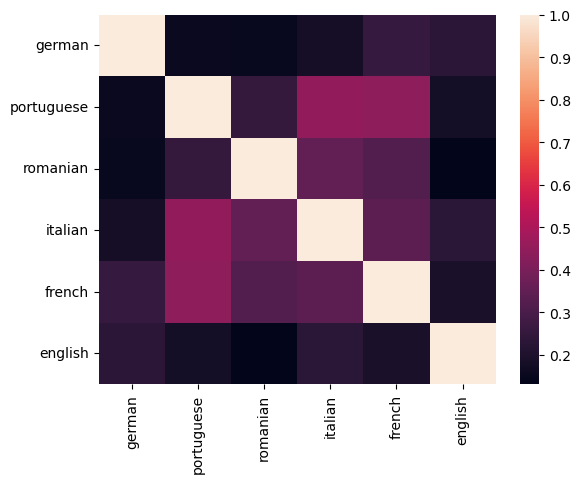

In [15]:
eval_languages.append("english")
counts_df = build_count_matrix(eval_languages, t250_folder)
norm_df = l2_normalize_rows(counts_df)

sim_df = cosine_similarity_matrix(norm_df)


sns.heatmap(sim_df)
print(sim_df)

Computed Similarity Scores:

| |german | portuguese | romanian | italian |  french | english|
|-|----|-----|----|----|---|---|
|german    | 1.000000  |  0.153738 | 0.150775| 0.179475 |0.255935| 0.226927|
|portuguese |0.153738   | 1.000000 | 0.251746| 0.449067 |0.442408| 0.173011|
|romanian   |0.150775  |  0.251746 | 1.000000| 0.350874 |0.316704| 0.128150|
|italian    |0.179475  |  0.449067 | 0.350874| 1.000000 |0.339435| 0.226329|
|french     |0.255935  |  0.442408 | 0.316704| 0.339435 |1.000000| 0.184800|
|english   | 0.226927 |   0.173011 | 0.128150| 0.226329 |0.184800| 1.000000|

Existing Similarity Scores:
| |german | portuguese | romanian | italian |  french | english|
|-|----|-----|----|----|---|---|
|german    | 1  |  N/A | N/A|N/A|0.29| 0.6|
|portuguese | N/A  | 1 | 0.72| N/A |0.75| N/A|
|romanian   | N/A |  0.72 | 1|  0.77|0.75| N/A|
|italian    | N/A | N/A  | 0.77| 1 |0.89|N/A |
|french     | 0.29 | 0.75  |0.75 | 0.89 |1|0.27 |
|english   | 0.6 |  N/A  |N/A | N/A|0.27| 1|

### Difference Between Similarity Scores

| Language Pair | Proposed Metric | Existing Score | Difference in Score |
|-|----|-----|---|
|German - French   |  0.26 |  0.29 | 0.03 |
|German - English   | 0.23  |  0.6 | 0.37|
|Portuguese - Romanian   | 0.25  | 0.72 | 0.47|
|Portuguese - French   | 0.44  |  0.75 | 0.32|
|Romanian - Italian   | 0.35 |  0.77 | 0.43|
|Romanian - French   | 0.31 |  0.75 | 0.44|
|Italian - French   | 0.33  |  0.89 | 0.56|
|French - English   | 0.18  |  0.27 | 0.09|

The average difference between the similarity scores computed using the proposed metric and the existing similarity scores sourced from Ethnologue is 0.33875.


## add stuff on cluster purity here (compare our results with this)

![Ethnologue Language Tree](language-tree.png)